## Задание
Продолжение работы с объединенным датасетом merged_data

**Задача 1** 
Выделить пользователей, которые делают упор на индивидуальные тренировки.
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:
+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:
+ Рассчитайте общее количество тренировок для каждого пользователя.
+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:
+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3** 
Проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).
+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).
+ Активные клиенты — это те, кто был активен в конкретном месяце.

Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.


Создайте три отдельных датафрейма:
+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.

Подсказка:
+ Используйте groupby и nunique() для подсчёта количества клиентов.
+ Для объединения датафреймов — merge.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [3]:
users_gr = df.copy()

In [4]:
users_gr = users_gr.groupby(['id_user', 'city', 'gender']).agg({'mon':'count',
                                                                'cnt_indiv':'sum',
                                                                'cnt_total':'sum',
                                                                'sum_total':'sum'}). \
                                                           reset_index().rename(columns = {'mon':'nmonths'})
users_gr.head()

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,female,9,33,33,58600
1,1001,Москва,female,11,23,129,124800
2,1002,Москва,male,11,64,128,166000
3,1004,Екатеринбург,male,9,18,18,32000
4,1005,СПб,female,2,7,7,12600


In [5]:
users_gr['share_indiv'] = users_gr['cnt_indiv'] / users_gr['cnt_total']

In [6]:
indiv_prefs_users = users_gr.loc[users_gr['share_indiv'] > 0.7].copy()

In [7]:
indiv_prefs_users.head()

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total,share_indiv
0,1000,СПб,female,9,33,33,58600,1.0
3,1004,Екатеринбург,male,9,18,18,32000,1.0
4,1005,СПб,female,2,7,7,12600,1.0
6,1007,Москва,female,4,5,5,9000,1.0
8,1009,Москва,female,4,9,9,16200,1.0


In [8]:
indiv_prefs_users['avg_check_per_mon'] = indiv_prefs_users['sum_total'] / indiv_prefs_users['nmonths']
indiv_prefs_users['avg_train_per_mon'] = indiv_prefs_users['cnt_total'] / indiv_prefs_users['nmonths']
indiv_prefs_users.head()

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total,share_indiv,avg_check_per_mon,avg_train_per_mon
0,1000,СПб,female,9,33,33,58600,1.0,6511.111111,3.666667
3,1004,Екатеринбург,male,9,18,18,32000,1.0,3555.555556,2.000000
4,1005,СПб,female,2,7,7,12600,1.0,6300.000000,3.500000
6,1007,Москва,female,4,5,5,9000,1.0,2250.000000,1.250000
8,1009,Москва,female,4,9,9,16200,1.0,4050.000000,2.250000


In [9]:
indiv_stats_city_gender = indiv_prefs_users.groupby(['city', 'gender']).agg({'id_user':'nunique',
                                                                             'avg_check_per_mon':'mean',
                                                                             'share_indiv':'mean',
                                                                             'avg_train_per_mon':'mean'}). \
                                                                        sort_values(by = 'avg_check_per_mon', ascending = False). \
                                                                        reset_index().rename(columns = {'id_user':'nusers'})
indiv_stats_city_gender

,city,gender,nusers,avg_check_per_mon,share_indiv,avg_train_per_mon
0,Москва,male,59,6915.316115,1.000000,3.872733
1,Казань,female,8,6297.500000,0.964744,3.756250
2,СПб,female,32,6093.278770,1.000000,3.399777
3,Екатеринбург,male,12,5832.394180,1.000000,3.256184
4,Москва,female,118,5565.425624,0.997881,3.141311
5,Екатеринбург,female,12,5391.746032,1.000000,3.009524
6,Казань,male,12,5229.378307,1.000000,2.931548
7,СПб,male,28,5024.889456,1.000000,2.821443


In [10]:
indiv_stats_city = indiv_prefs_users.groupby('city').agg({'id_user':'nunique',
                                                                             'avg_check_per_mon':'mean',
                                                                             'share_indiv':'mean',
                                                                             'avg_train_per_mon':'mean'}). \
                                                                        sort_values(by = 'avg_check_per_mon', ascending = False). \
                                                                        reset_index().rename(columns = {'id_user':'nusers'})
indiv_stats_city

,city,nusers,avg_check_per_mon,share_indiv,avg_train_per_mon
0,Москва,177,6015.389121,0.998588,3.385118
1,Казань,20,5656.626984,0.985897,3.261429
2,Екатеринбург,24,5612.070106,1.000000,3.132854
3,СПб,60,5594.697090,1.000000,3.129888


In [11]:
indiv_stats_gender = indiv_prefs_users.groupby('gender').agg({'id_user':'nunique',
                                                                             'avg_check_per_mon':'mean',
                                                                             'share_indiv':'mean',
                                                                             'avg_train_per_mon':'mean'}). \
                                                                        sort_values(by = 'avg_check_per_mon', ascending = False). \
                                                                        reset_index().rename(columns = {'id_user':'nusers'})
indiv_stats_gender

,gender,nusers,avg_check_per_mon,share_indiv,avg_train_per_mon
0,male,111,6139.115544,1.00000,3.439139
1,female,170,5686.977039,0.99687,3.209599


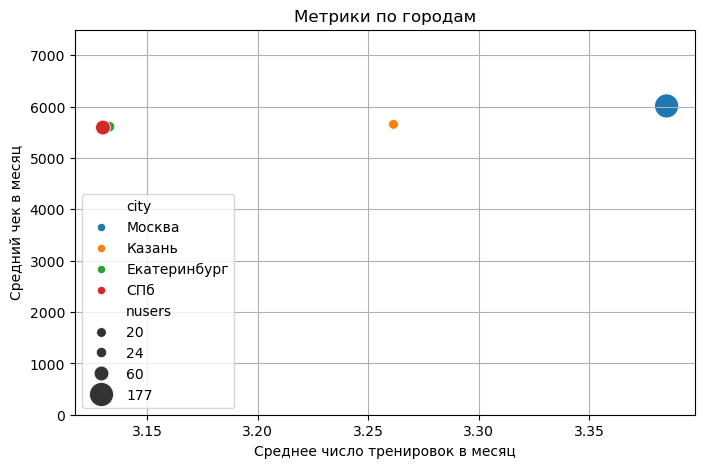

In [12]:
plt.figure(figsize=(8, 5))
#plt.xlim(0, 1)
plt.ylim(0, 7500)
sns.scatterplot(data = indiv_stats_city,
               x = 'avg_train_per_mon',
               y = 'avg_check_per_mon',
               hue = 'city',
                size='nusers',
                sizes=(50, 300))
plt.xlabel('Среднее число тренировок в месяц')
plt.ylabel('Средний чек в месяц')
plt.title('Метрики по городам')
plt.legend()
plt.grid(True)
plt.show()

### Задача 2. Топ-10 клиентов

In [13]:
users_gr_2 = df.groupby('id_user').agg({'cnt_total':'sum'}).reset_index().sort_values('cnt_total', ascending = False).head(10)
users_gr_2

,id_user,cnt_total
319,1381,159
12,1013,151
551,1657,144
420,1506,138
780,1929,130
1,1001,129
474,1570,129
2,1002,128
485,1582,127
168,1194,127


In [14]:
users_gr_2_lst = users_gr_2['id_user'].tolist()
users_gr_2_lst

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1582, 1194]

In [15]:
top_10_by_train_cnt = df[df['id_user'].isin(users_gr_2_lst)]
top_10_by_train_cnt.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
10,1001,2023-02,11,3,8800,5400,14,14200,2023-01,2023-12,Москва,35.0,female
11,1001,2023-03,8,6,6400,10800,14,17200,2023-01,2023-12,Москва,35.0,female
12,1001,2023-04,9,5,7200,9000,14,16200,2023-01,2023-12,Москва,35.0,female
13,1001,2023-05,3,7,2400,11200,10,13600,2023-01,2023-12,Москва,35.0,female


In [16]:
top_10_by_train_cnt_gr = top_10_by_train_cnt.groupby(['id_user', 'city', 'gender']). \
                                             agg({'mon':'count',
                                                  'cnt_total':'sum'}).reset_index(). \
                                             rename(columns = {'mon': 'nmonths'})
top_10_by_train_cnt_gr

,id_user,city,gender,nmonths,cnt_total
0,1001,Москва,female,11,129
1,1002,Москва,male,11,128
2,1013,Москва,male,11,151
3,1194,СПб,female,12,127
4,1381,Москва,female,12,159
5,1506,Москва,female,10,138
6,1570,Екатеринбург,male,11,129
7,1582,Екатеринбург,male,8,127
8,1657,СПб,male,10,144
9,1929,Москва,male,11,130


In [17]:
top_10_by_train_cnt_gr['avg_train_per_month'] = top_10_by_train_cnt_gr['cnt_total'] / top_10_by_train_cnt_gr['nmonths']
top_10_by_train_cnt_gr.sort_values('avg_train_per_month', ascending = False).reset_index()

,index,id_user,city,gender,nmonths,cnt_total,avg_train_per_month
0,7,1582,Екатеринбург,male,8,127,15.875000
1,8,1657,СПб,male,10,144,14.400000
2,5,1506,Москва,female,10,138,13.800000
3,2,1013,Москва,male,11,151,13.727273
4,4,1381,Москва,female,12,159,13.250000
5,9,1929,Москва,male,11,130,11.818182
6,0,1001,Москва,female,11,129,11.727273
7,6,1570,Екатеринбург,male,11,129,11.727273
8,1,1002,Москва,male,11,128,11.636364
9,3,1194,СПб,female,12,127,10.583333


In [18]:
top_10_graphics = top_10_by_train_cnt_gr.groupby(['city', 'gender']).size().unstack(fill_value=0)
top_10_graphics.head()

gender,female,male
city,,
Екатеринбург,0,2
Москва,3,3
СПб,1,1


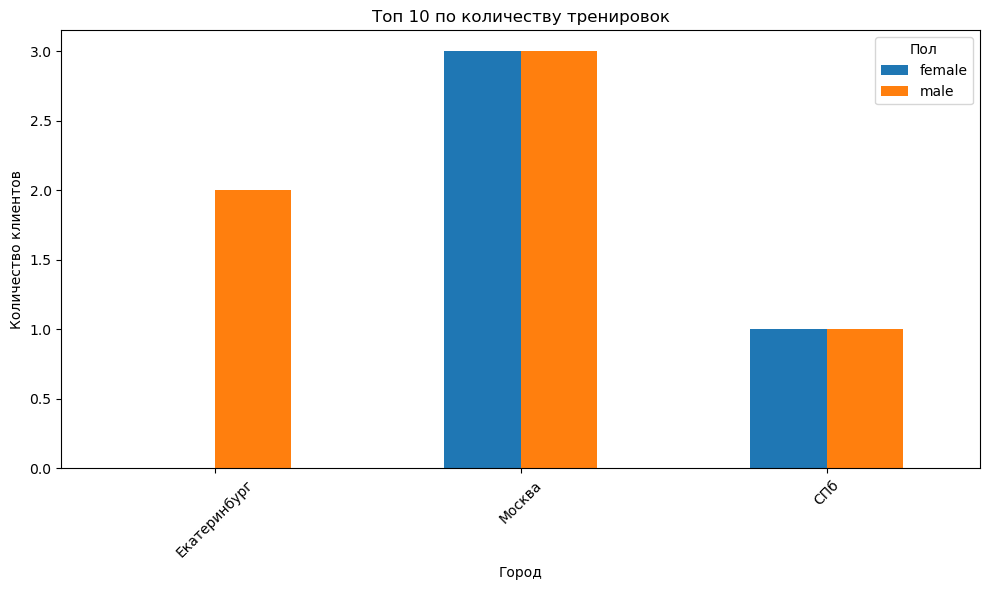

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
top_10_graphics.plot(kind='bar', ax=ax)
ax.set_title('Топ 10 по количеству тренировок')
ax.set_ylabel('Количество клиентов')
ax.set_xlabel('Город')
ax.legend(title='Пол')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
pivot_top_10 = top_10_by_train_cnt_gr.pivot_table(index='city', 
                                                  columns='gender', 
                                                  values='avg_train_per_month', 
                                                  aggfunc='mean', 
                                                  fill_value=0
                                                  )
print(pivot_top_10)

gender           female       male
city                              
Екатеринбург   0.000000  13.801136
Москва        12.925758  12.393939
СПб           10.583333  14.400000


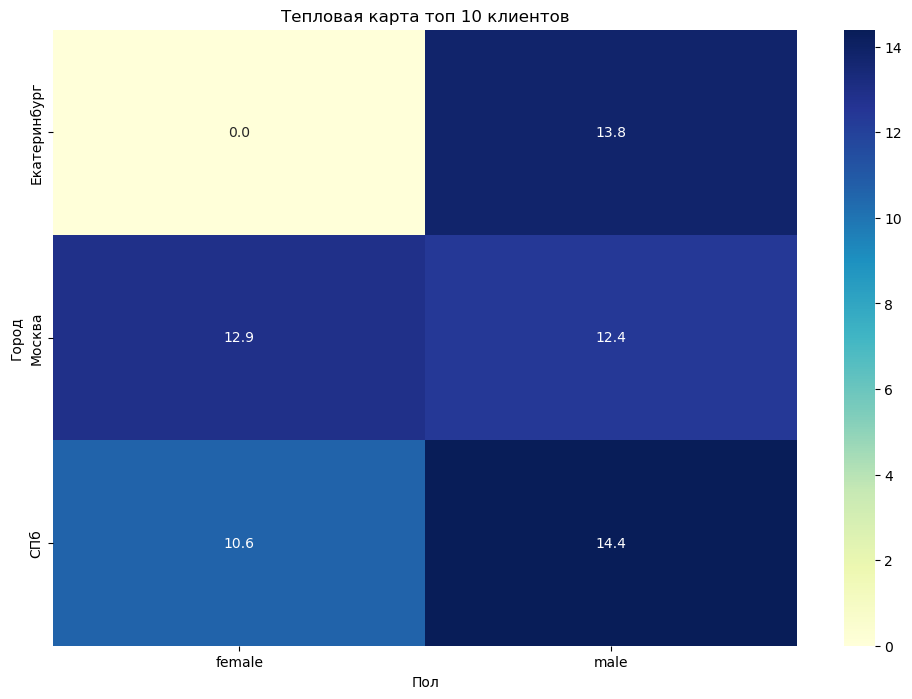

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_top_10, annot = True, fmt = ".1f", cmap = 'YlGnBu')
plt.xlabel('Пол')
plt.ylabel('Город')
plt.title('Тепловая карта топ 10 клиентов')
plt.show()

In [22]:
# Самые активные - мужчины в СПб, в Москве немного активнее женщины, в ЕКб только мужчины 
# (анализ основан только на топ-10 посетителях и не включает общую активность по городам и полам)

### Задача 3. Динамика клиентской базы

In [23]:
df.head(50)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
5,1000,2023-08,0,3,0,5400,3,5400,2023-03,2023-12,СПб,44.0,female
6,1000,2023-09,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
7,1000,2023-11,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
8,1000,2023-12,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female


In [24]:
users_first_month = df.groupby('id_user')['mon'].min().reset_index()
users_first_month

,id_user,mon
0,1000,2023-03
1,1001,2023-01
2,1002,2023-02
3,1004,2023-02
4,1005,2023-07
...,...,...
833,1992,2023-01
834,1993,2023-08
835,1994,2023-10
836,1995,2023-06


In [25]:
new_clients_df = users_first_month.groupby('mon').size().reset_index(name='new_clients')
new_clients_df.head()

,mon,new_clients
0,2023-01,337
1,2023-02,88
2,2023-03,83
3,2023-04,62
4,2023-05,57


In [26]:
users_last_months = df.groupby('id_user')['mon'].max().reset_index()
users_last_months.head()

,id_user,mon
0,1000,2023-12
1,1001,2023-12
2,1002,2023-12
3,1004,2023-10
4,1005,2023-10


In [27]:
gone_clients_df = users_last_months.groupby('mon').size().reset_index(name='gone_clients')
gone_clients_df.head()

,mon,gone_clients
0,2023-01,15
1,2023-02,22
2,2023-03,37
3,2023-04,21
4,2023-05,21


In [28]:
active_clients_df = df.groupby('mon')['id_user'].nunique().reset_index(name='active_clients')
active_clients_df.head()

,mon,active_clients
0,2023-01,337
1,2023-02,350
2,2023-03,355
3,2023-04,345
4,2023-05,360


In [29]:
new_plus_gone_users_df = pd.merge(new_clients_df, gone_clients_df, on = 'mon', how = 'outer')
new_plus_gone_users_df.head()

,mon,new_clients,gone_clients
0,2023-01,337,15
1,2023-02,88,22
2,2023-03,83,37
3,2023-04,62,21
4,2023-05,57,21


In [30]:
monthly_clients = pd.merge(new_plus_gone_users_df, active_clients_df, on = 'mon', how = 'outer')
monthly_clients.head(20)

,mon,new_clients,gone_clients,active_clients
0,2023-01,337,15,337
1,2023-02,88,22,350
2,2023-03,83,37,355
3,2023-04,62,21,345
4,2023-05,57,21,360
5,2023-06,51,13,383
6,2023-07,48,33,412
7,2023-08,35,33,423
8,2023-09,28,55,429
9,2023-10,27,101,441


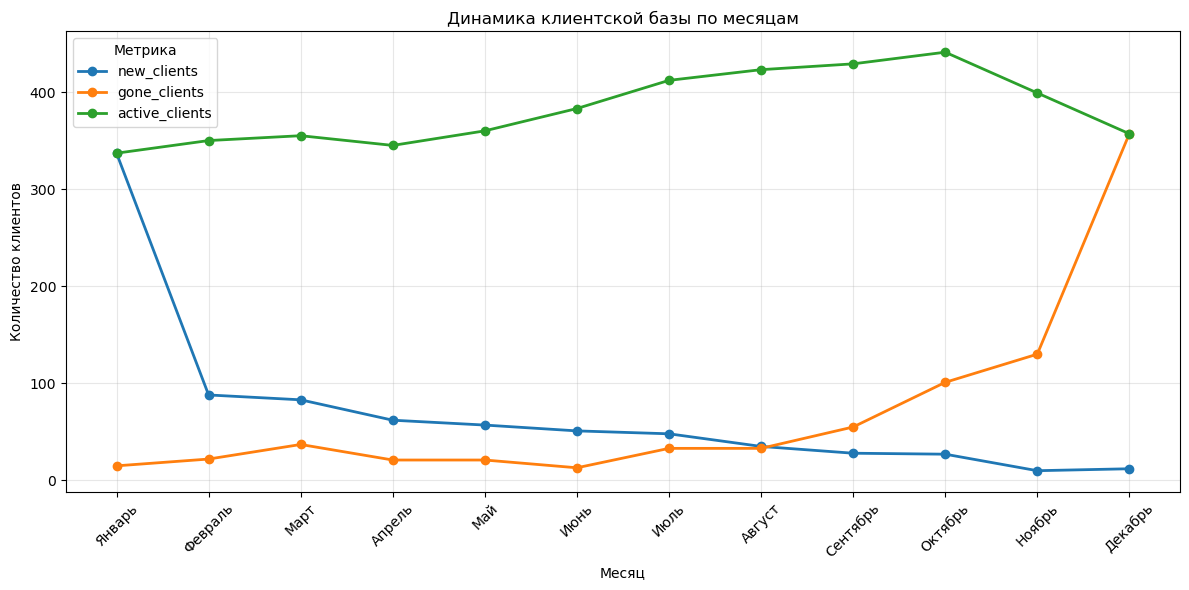

In [31]:
months = ['Январь','Февраль','Март','Апрель','Май','Июнь','Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
monthly_clients.plot(kind='line', figsize=(12, 6), linewidth=2, marker='o')
plt.title('Динамика клиентской базы по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество клиентов')
plt.xticks(range(len(months)), months, rotation=45)
plt.legend(title='Метрика')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()